In [29]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [30]:
import os

print("gdrive MyDrive exists:", os.path.exists("/content/gdrive/MyDrive"))
print("drive MyDrive exists:", os.path.exists("/content/drive/MyDrive"))

gdrive MyDrive exists: True
drive MyDrive exists: True


In [31]:
!find /content/gdrive/MyDrive -name "transformer_lookback_metrics_L*.csv"

/content/gdrive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/transformer_lookback_metrics_L10.csv
/content/gdrive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/transformer_lookback_metrics_L20.csv
/content/gdrive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/transformer_lookback_metrics_L30.csv
/content/gdrive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/transformer_lookback_metrics_L60.csv


In [32]:
import os
import pandas as pd

PROJECT_ROOT = "/content/gdrive/MyDrive/thesis_rl_trading_final"
TAB_DIR = f"{PROJECT_ROOT}/outputs/tables_ch5"
FIG_DIR = f"{PROJECT_ROOT}/outputs/figures_ch5"

print("PROJECT_ROOT exists:", os.path.exists(PROJECT_ROOT))
print("TAB_DIR exists:", os.path.exists(TAB_DIR))

files = {
    10: f"{TAB_DIR}/transformer_lookback_metrics_L10.csv",
    20: f"{TAB_DIR}/transformer_lookback_metrics_L20.csv",
    30: f"{TAB_DIR}/transformer_lookback_metrics_L30.csv",
    60: f"{TAB_DIR}/transformer_lookback_metrics_L60.csv",
}

for L, path in files.items():
    print(f"L{L} exists:", os.path.exists(path), path)

dfs = []
for L, path in files.items():
    df = pd.read_csv(path)
    df["lookback"] = L
    dfs.append(df)

lookback_df = (
    pd.concat(dfs, ignore_index=True)
    .sort_values("lookback")
    .reset_index(drop=True)
)

display(lookback_df)

PROJECT_ROOT exists: True
TAB_DIR exists: True
L10 exists: True /content/gdrive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/transformer_lookback_metrics_L10.csv
L20 exists: True /content/gdrive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/transformer_lookback_metrics_L20.csv
L30 exists: True /content/gdrive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/transformer_lookback_metrics_L30.csv
L60 exists: True /content/gdrive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/transformer_lookback_metrics_L60.csv


,lookback,model,cumulative_return,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost
0,10,Transformer-PPO,0.278002,1.861412,-0.111744,0.086846,0.021798
1,20,Transformer-PPO,0.214492,1.683227,-0.079430,0.056546,0.014193
2,30,Transformer-PPO,0.200972,1.648115,-0.075782,0.053561,0.013444
3,60,Transformer-PPO,0.192800,1.609331,-0.068710,0.076022,0.019082


In [33]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=lookback_df)

https://docs.google.com/spreadsheets/d/12BYgmaQ89-pYS8B6Kk1s1s9haM3-BpdwXvQkMtv0jEw/edit#gid=0


In [34]:
summary_path = f"{TAB_DIR}/lookback_sensitivity_summary_5y.csv"
lookback_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)
display(lookback_df)

Saved: /content/gdrive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/lookback_sensitivity_summary_5y.csv


,lookback,model,cumulative_return,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost
0,10,Transformer-PPO,0.278002,1.861412,-0.111744,0.086846,0.021798
1,20,Transformer-PPO,0.214492,1.683227,-0.079430,0.056546,0.014193
2,30,Transformer-PPO,0.200972,1.648115,-0.075782,0.053561,0.013444
3,60,Transformer-PPO,0.192800,1.609331,-0.068710,0.076022,0.019082


In [35]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=lookback_df)

https://docs.google.com/spreadsheets/d/1ka7jdgrs9t5th5t2l4FxYpGaRHY1_NcYussPYLwMLRY/edit#gid=0


In [36]:
rank_df = lookback_df.copy()

rank_df["rank_cumret"] = rank_df["cumulative_return"].rank(ascending=False, method="min")
rank_df["rank_sharpe"] = rank_df["sharpe_approx"].rank(ascending=False, method="min")

# max_drawdown: càng ít âm càng tốt, nên ascending=False
rank_df["rank_mdd"] = rank_df["max_drawdown"].rank(ascending=False, method="min")

# turnover và trading cost: càng thấp càng tốt
rank_df["rank_turnover"] = rank_df["avg_turnover"].rank(ascending=True, method="min")
rank_df["rank_cost"] = rank_df["total_trading_cost"].rank(ascending=True, method="min")

rank_df["avg_rank"] = rank_df[
    ["rank_cumret", "rank_sharpe", "rank_mdd", "rank_turnover", "rank_cost"]
].mean(axis=1)

rank_path = f"{TAB_DIR}/lookback_sensitivity_ranked_5y.csv"
rank_df.to_csv(rank_path, index=False)

print("Saved:", rank_path)
display(rank_df)

Saved: /content/gdrive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/lookback_sensitivity_ranked_5y.csv


,lookback,model,cumulative_return,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,rank_cumret,rank_sharpe,rank_mdd,rank_turnover,rank_cost,avg_rank
0,10,Transformer-PPO,0.278002,1.861412,-0.111744,0.086846,0.021798,1.0,1.0,4.0,4.0,4.0,2.8
1,20,Transformer-PPO,0.214492,1.683227,-0.079430,0.056546,0.014193,2.0,2.0,3.0,2.0,2.0,2.2
2,30,Transformer-PPO,0.200972,1.648115,-0.075782,0.053561,0.013444,3.0,3.0,2.0,1.0,1.0,2.0
3,60,Transformer-PPO,0.192800,1.609331,-0.068710,0.076022,0.019082,4.0,4.0,1.0,3.0,3.0,3.0


In [37]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=rank_df)

https://docs.google.com/spreadsheets/d/1tiEXTmeoAiEFHI2xiShssApOg7cvJNEkahxpms2lRXE/edit#gid=0


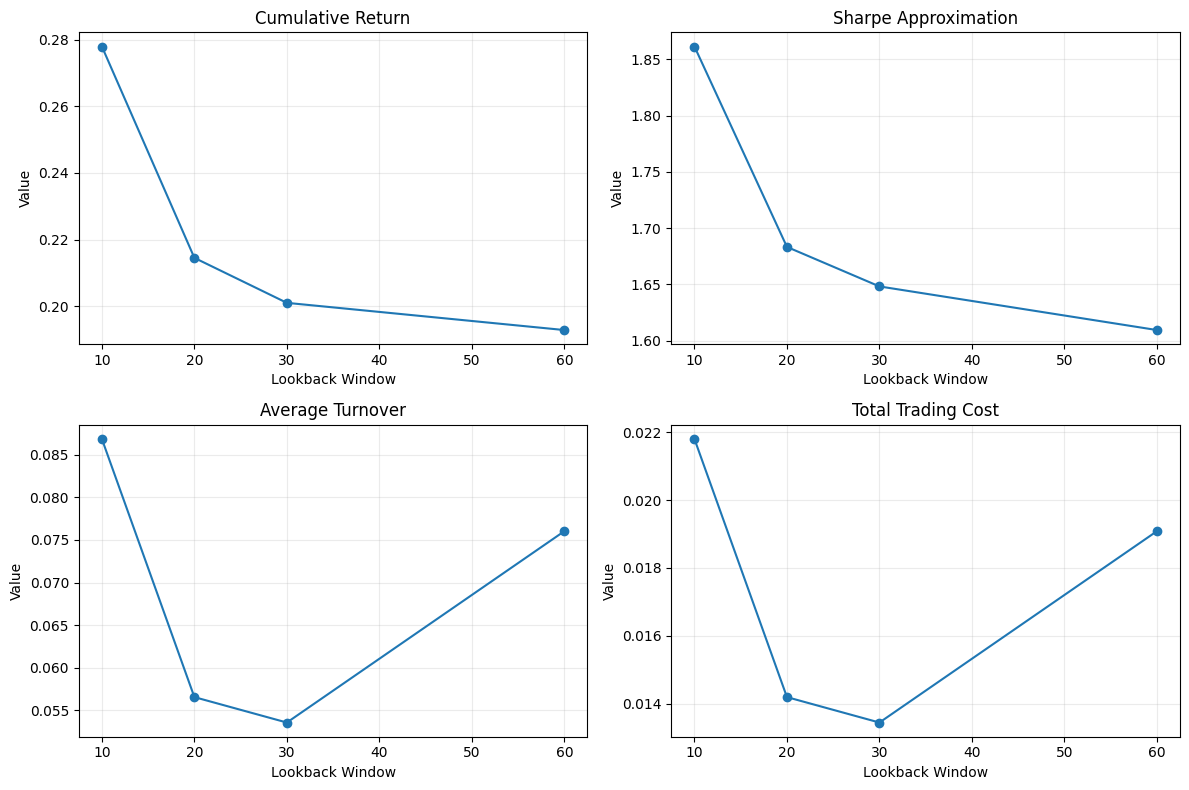

Saved: /content/gdrive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5/lookback_sensitivity_5y.png


In [38]:
import os
import matplotlib.pyplot as plt

os.makedirs(FIG_DIR, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

plots = [
    ("cumulative_return", "Cumulative Return"),
    ("sharpe_approx", "Sharpe Approximation"),
    ("avg_turnover", "Average Turnover"),
    ("total_trading_cost", "Total Trading Cost"),
]

for ax, (col, title) in zip(axes, plots):
    ax.plot(lookback_df["lookback"], lookback_df[col], marker="o")
    ax.set_title(title)
    ax.set_xlabel("Lookback Window")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.25)

plt.tight_layout()

fig_path = f"{FIG_DIR}/lookback_sensitivity_5y.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

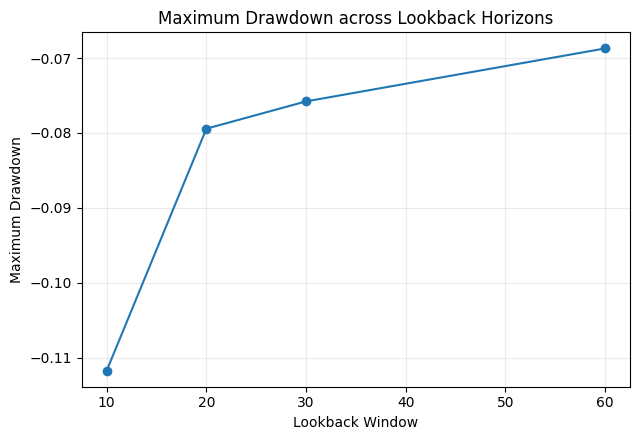

Saved: /content/gdrive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5/lookback_mdd_5y.png


In [39]:
plt.figure(figsize=(6.5, 4.5))
plt.plot(lookback_df["lookback"], lookback_df["max_drawdown"], marker="o")

plt.title("Maximum Drawdown across Lookback Horizons")
plt.xlabel("Lookback Window")
plt.ylabel("Maximum Drawdown")
plt.grid(True, alpha=0.25)

plt.tight_layout()

mdd_path = f"{FIG_DIR}/lookback_mdd_5y.png"
plt.savefig(mdd_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", mdd_path)